In [1]:
import os
# import ray

In [2]:
import sys

In [3]:
sys.version

'3.10.19 (main, Oct 10 2025, 08:52:10) [GCC 13.3.0]'

In [4]:
import ray

In [5]:
sys.path.append("..")
import warnings
warnings.filterwarnings("ignore")
from dotenv import load_dotenv
load_dotenv()
%load_ext autoreload
%autoreload 2

In [6]:
if ray.is_initialized():
    ray.shutdown()
ray.init()

2026-02-18 19:50:46,722	INFO worker.py:1633 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


Python version:,3.10.19
Ray version:,2.7.0
Dashboard:,http://127.0.0.1:8265


(MapBatches(preprocess) pid=6404) /home/krekken/madewithml/venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
(MapBatches(preprocess) pid=6404)   warnings.warn(
(MapBatches(preprocess) pid=10642) /home/krekken/madewithml/venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
(MapBatches(preprocess) pid=10642)   warnings.warn(


In [7]:
ray.cluster_resources()

{'node:__internal_head__': 1.0,
 'node:192.168.1.12': 1.0,
 'memory': 4210925568.0,
 'object_store_memory': 2105462784.0,
 'GPU': 1.0,
 'accelerator_type:G': 1.0,
 'CPU': 20.0}

In [8]:
num_workers_preprocess = 15
resources_per_worker_preprocess = {"CPU":1, "GPU":0}
num_workers_finetune = 1
resources_per_worker_finetune = {"CPU":1, "GPU":1}


# Data

## Data Ingestion

In [9]:
import pandas as pd

In [10]:
DATASET_LOC = "https://raw.githubusercontent.com/GokuMohandas/Made-With-ML/main/datasets/dataset.csv"
df = pd.read_csv(DATASET_LOC)
df.head()

,id,created_on,title,description,tag
0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world...,Bringing theory to experiment is cool. We can ...,computer-vision
1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for C...",The beauty of the work lies in the way it arch...,computer-vision
2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, cla...",other
3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search pape...,other
4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: ...",other


## Data Splitting

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
df["tag"].value_counts()

tag
natural-language-processing    310
computer-vision                285
other                          106
mlops                           63
Name: count, dtype: int64

In [13]:
# Split dataset
test_size = 0.2
train_df, val_df = train_test_split(df, stratify=df["tag"], test_size=test_size, random_state=1234)

In [14]:
train_df["tag"].value_counts()

tag
natural-language-processing    248
computer-vision                228
other                           85
mlops                           50
Name: count, dtype: int64

In [15]:
val_df["tag"].value_counts()

tag
natural-language-processing    62
computer-vision                57
other                          21
mlops                          13
Name: count, dtype: int64

In [16]:
val_df["tag"].value_counts() * int((1-test_size) / test_size)

tag
natural-language-processing    248
computer-vision                228
other                           84
mlops                           52
Name: count, dtype: int64

## Exploratory Data Analysis

In [17]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from wordcloud import WordCloud, STOPWORDS
sns.set_theme()
warnings.filterwarnings("ignore")

In [18]:
# Most common tags
all_tags = Counter(df["tag"])
all_tags.most_common()

[('natural-language-processing', 310),
 ('computer-vision', 285),
 ('other', 106),
 ('mlops', 63)]

In [19]:
# Plot tag frequencies

tags, tag_counts = zip(*all_tags.most_common())
type(tags)

tuple

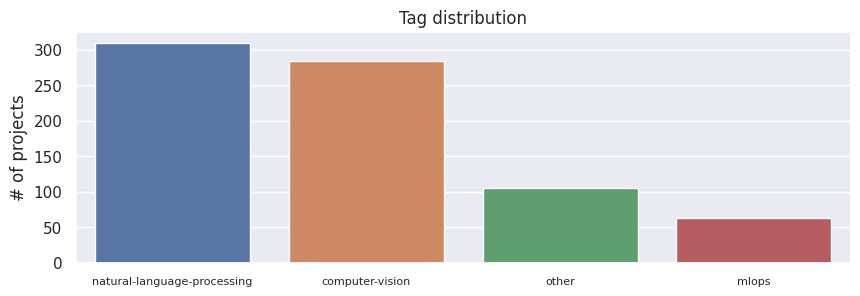

In [20]:
plt.figure(figsize=(10,3))
ax = sns.barplot(x=list(tags), y = list(tag_counts))
ax.set_xticklabels(tags, fontsize=8)
plt.title("Tag distribution")
plt.ylabel("# of projects")

plt.show()

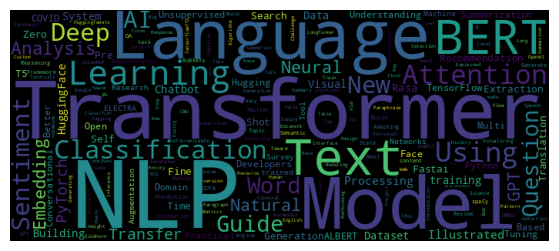

In [21]:
# Most frequent tokens for each tag
tag="natural-language-processing"
plt.figure(figsize=(10,3))
subset = df[df["tag"] == tag]
text = subset["title"].values
cloud = WordCloud(
    stopwords=STOPWORDS, background_color="black", collocations=False,
    width=700, height=300
).generate(" ".join(text))
plt.axis("off")
plt.imshow(cloud)

In [22]:
df.head(10)

,id,created_on,title,description,tag
0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world...,Bringing theory to experiment is cool. We can ...,computer-vision
1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for C...",The beauty of the work lies in the way it arch...,computer-vision
2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, cla...",other
3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search pape...,other
4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: ...",other
5,27,2020-03-07 23:18:15,APPNP and PPNP,"A PyTorch implementation of ""Predict then Prop...",other
6,28,2020-03-07 23:23:46,Attributed Social Network Embedding,A sparsity aware and memory efficient implemen...,other
7,29,2020-03-07 23:45:38,Signed Graph Convolutional Network,"A PyTorch implementation of ""Signed Graph Conv...",other
8,45,2020-03-08 00:39:08,SimGNN,"A PyTorch implementation of ""SimGNN: A Neural ...",other
9,61,2020-03-16 17:35:22,Using JAX to Improve Separable Image Filters,Optimizing the filters to improve the filtered...,computer-vision


# Data Preprocessing

In [23]:
import json
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

### Feature Engineering

In [24]:
df["text"] = df["title"] + " " + df["description"]

In [25]:
df.head()

,id,created_on,title,description,tag,text
0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world...,Bringing theory to experiment is cool. We can ...,computer-vision,Comparison between YOLO and RCNN on real world...
1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for C...",The beauty of the work lies in the way it arch...,computer-vision,"Show, Infer & Tell: Contextual Inference for C..."
2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, cla...",other,Awesome Graph Classification A collection of i...
3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search pape...,other,Awesome Monte Carlo Tree Search A curated list...
4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: ...",other,"AttentionWalk A PyTorch Implementation of ""Wat..."


### Clean Text

In [26]:
nltk.download("stopwords")
STOPWORDS = stopwords.words("english")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/krekken/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
def clean_text(text, stopwords=STOPWORDS):
    """Clean raw text string."""
    # Lower
    text = text.lower()

    # Remove stopwords
    pattern = re.compile(r'\b(' + r"|".join(stopwords) + r")\b\s*")
    text = pattern.sub('', text)

    # Spacing and filters
    text = re.sub(r"([!\"'#$%&()*\+,-./:;<=>?@\\\[\]^_`{|}~])", r" \1 ", text)  # add spacing
    text = re.sub("[^A-Za-z0-9]+", " ", text)  # remove non alphanumeric chars
    text = re.sub(" +", " ", text)  # remove multiple spaces
    text = text.strip()  # strip white space at the ends
    text = re.sub(r"http\S+", "", text)  #  remove links
    
    return text

In [28]:
# Apply to our dataframe
original_df = df.copy()
df.text = df.text.apply(clean_text)
print(f"{original_df.text.values[0]}\n{df.text.values[0]}")

Comparison between YOLO and RCNN on real world videos Bringing theory to experiment is cool. We can easily train models in colab and find the results in minutes.
comparison yolo rcnn real world videos bringing theory experiment cool easily train models colab find results minutes


In [29]:
df.head()

,id,created_on,title,description,tag,text
0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world...,Bringing theory to experiment is cool. We can ...,computer-vision,comparison yolo rcnn real world videos bringin...
1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for C...",The beauty of the work lies in the way it arch...,computer-vision,show infer tell contextual inference creative ...
2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, cla...",other,awesome graph classification collection import...
3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search pape...,other,awesome monte carlo tree search curated list m...
4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: ...",other,attentionwalk pytorch implementation watch ste...


In [30]:
# Dataframe Cleanup
df = df.drop(columns=["id", "created_on", "title", "description"], errors="ignore")
df = df.dropna(subset=["tag"]) # drop nulls
df = df[["text", "tag"]] # rearrange
df.head()

,text,tag
0,comparison yolo rcnn real world videos bringin...,computer-vision
1,show infer tell contextual inference creative ...,computer-vision
2,awesome graph classification collection import...,other
3,awesome monte carlo tree search curated list m...,other
4,attentionwalk pytorch implementation watch ste...,other


### Encoding

In [31]:
# Label to index

tags = train_df["tag"].unique().tolist()
num_classes = len(tags)
class_to_index = {tag: i for i,tag in enumerate(tags)}
class_to_index

{'mlops': 0,
 'natural-language-processing': 1,
 'computer-vision': 2,
 'other': 3}

In [32]:
#Map labels
df["tag"] = df["tag"].map(class_to_index)
df.head()

,text,tag
0,comparison yolo rcnn real world videos bringin...,2
1,show infer tell contextual inference creative ...,2
2,awesome graph classification collection import...,3
3,awesome monte carlo tree search curated list m...,3
4,attentionwalk pytorch implementation watch ste...,3


In [33]:
def decode(indices, index_to_class):
    return [index_to_class[index] for index in indices]

In [34]:
index_to_class = {v: k for k, v in class_to_index.items()}
decode(df.head()["tag"].values, index_to_class)

['computer-vision', 'computer-vision', 'other', 'other', 'other']

### Tokenizer

In [35]:
import numpy as np
from transformers import BertTokenizer

In [36]:
# Bert Tokenizer
tokenizer = BertTokenizer.from_pretrained("allenai/scibert_scivocab_uncased", return_dict = False)
tokenizer

BertTokenizer(name_or_path='allenai/scibert_scivocab_uncased', vocab_size=31090, model_max_length=1000000000000000019884624838656, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True)

In [37]:
text = "Transfer learning with transformers for text classification."
encoded_inputs = tokenizer([text], return_tensors="np", padding="longest")
print("input_ids:", encoded_inputs["input_ids"])
print("attention_mask:", encoded_inputs["attention_mask"])
print(tokenizer.decode(encoded_inputs["input_ids"][0]))

input_ids: [[  102  2268  1904   190 29155   168  3267  2998   205   103]]
attention_mask: [[1 1 1 1 1 1 1 1 1 1]]
[CLS] transfer learning with transformers for text classification. [SEP]


In [38]:
def tokenize(batch):
    tokenizer = BertTokenizer.from_pretrained("allenai/scibert_scivocab_uncased", return_dict=False)
    encoded_inputs = tokenizer(batch["text"].tolist(), padding="longest", return_tensors="np")
    return dict(ids=encoded_inputs["input_ids"], masks=encoded_inputs["attention_mask"], targest=np.array(batch["tag"]))

In [39]:
tokenize(df.head(1))

{'ids': array([[  102,  2029,  1778,   609,  6446,  4857,  1332,  2399, 13572,
         19125,  1983,  1954,  6240,  3717,  7434,  1262,   537,   201,
          1040,   545,  4714,   103]]),
 'masks': array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]),
 'targest': array([2])}

### Best practices

In [40]:
def preprocess(df, class_to_index):
    df["text"] = df["title"] + " " + df["description"]
    df["text"] = df["text"].apply(clean_text)
    df = df.drop(columns=["title", "id", "created_on", "description"])
    df = df[["text", "tag"]]
    df["tag"] = df["tag"].map(class_to_index)
    outputs = tokenize(df)

    return outputs

In [41]:
# apply
preprocess(df=train_df, class_to_index=class_to_index)

{'ids': array([[  102,   856,   532, ...,     0,     0,     0],
        [  102,  2177, 29155, ...,     0,     0,     0],
        [  102,  2180,  3241, ...,     0,     0,     0],
        ...,
        [  102,   453,  2068, ...,  5730,   432,   103],
        [  102, 11268,  1782, ...,     0,     0,     0],
        [  102,  1596,   122, ...,     0,     0,     0]]),
 'masks': array([[1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]]),
 'targest': array([0, 1, 1, 1, 1, 2, 1, 2, 3, 1, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 0, 1,
        1, 1, 1, 1, 2, 1, 2, 0, 3, 2, 0, 1, 1, 1, 1, 2, 1, 1, 0, 2, 3, 3,
        3, 0, 2, 1, 3, 3, 1, 1, 1, 1, 2, 1, 2, 2, 2, 3, 2, 1, 1, 3, 1, 0,
        1, 2, 2, 2, 3, 2, 3, 2, 3, 2, 1, 1, 3, 3, 3, 1, 1, 2, 3, 0, 1, 1,
        1, 1, 3, 3, 0, 2, 3, 2, 2, 1, 1, 3, 2, 3, 1, 1, 1, 1, 2, 0, 0, 2,
        1, 1, 2, 2, 1, 1, 0, 3, 1

In [ ]:
# Deterministic
ray.data.DataContext.get_current().execution_options.preserve_order = True

### Ingestion

In [43]:
ds = ray.data.read_csv(DATASET_LOC)
ds = ds.random_shuffle(seed=1234)
ds.take(1)

2026-02-18 19:54:46,339	INFO read_api.py:406 -- To satisfy the requested parallelism of 40, each read task output is split into 40 smaller blocks.
2026-02-18 19:54:46,369	INFO dataset.py:2380 -- Tip: Use `take_batch()` instead of `take() / show()` to return records in pandas or numpy batch format.
2026-02-18 19:54:46,373	INFO streaming_executor.py:93 -- Executing DAG InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV->SplitBlocks(40)] -> AllToAllOperator[RandomShuffle] -> LimitOperator[limit=1]
2026-02-18 19:54:46,376	INFO streaming_executor.py:94 -- Execution config: ExecutionOptions(resource_limits=ExecutionResources(cpu=None, gpu=None, object_store_memory=None), locality_with_output=False, preserve_order=True, actor_locality_enabled=True, verbose_progress=False)
2026-02-18 19:54:46,379	INFO streaming_executor.py:96 -- Tip: For detailed progress reporting, run `ray.data.DataContext.get_current().execution_options.verbose_progress = True`


- RandomShuffle 1:   0%|          | 0/1600 [00:00<?, ?it/s]

Shuffle Map 2:   0%|          | 0/1600 [00:00<?, ?it/s]

Shuffle Reduce 3:   0%|          | 0/1600 [00:00<?, ?it/s]

Running 0:   0%|          | 0/1 [00:00<?, ?it/s]

[{'id': 941,
  'created_on': datetime.datetime(2020, 5, 22, 3, 21, 10),
  'title': 'BiT: Exploring Large-Scale Pre-training for Compute',
  'description': 'We are excited to share the best BiT models pre-trained on public datasets, along with code in TF2, Jax, and PyTorch. ',
  'tag': 'computer-vision'}]

### Splitting

In [ ]:
import sys
sys.path.append("..")
from madewithml.data import stratify_split

In [45]:
sys.path

['/home/krekken/madewithml/venv/lib/python3.10/site-packages/ray/thirdparty_files',
 '/usr/lib/python310.zip',
 '/usr/lib/python3.10',
 '/usr/lib/python3.10/lib-dynload',
 '',
 '/home/krekken/madewithml/venv/lib/python3.10/site-packages',
 '..',
 '..']

In [46]:
test_size = 0.2
train_ds, val_ds = stratify_split(ds, stratify="tag", test_size=test_size)

2026-02-18 19:57:46,059	INFO streaming_executor.py:93 -- Executing DAG InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV->SplitBlocks(40)] -> AllToAllOperator[RandomShuffle] -> LimitOperator[limit=1]
2026-02-18 19:57:46,061	INFO streaming_executor.py:94 -- Execution config: ExecutionOptions(resource_limits=ExecutionResources(cpu=None, gpu=None, object_store_memory=None), locality_with_output=False, preserve_order=True, actor_locality_enabled=True, verbose_progress=False)
2026-02-18 19:57:46,061	INFO streaming_executor.py:96 -- Tip: For detailed progress reporting, run `ray.data.DataContext.get_current().execution_options.verbose_progress = True`


- RandomShuffle 1:   0%|          | 0/1600 [00:00<?, ?it/s]

Shuffle Map 2:   0%|          | 0/1600 [00:00<?, ?it/s]

Shuffle Reduce 3:   0%|          | 0/1600 [00:00<?, ?it/s]

Running 0:   0%|          | 0/1 [00:00<?, ?it/s]

### Preprocessing

In [47]:
# Mapping
tags = train_ds.unique(column="tag")
tags

2026-02-18 20:01:17,677	INFO streaming_executor.py:93 -- Executing DAG InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV->SplitBlocks(40)] -> AllToAllOperator[RandomShuffle] -> AllToAllOperator[Sort] -> AllToAllOperator[MapBatches(group_fn)->MapBatches(_filter_split)->RandomShuffle] -> LimitOperator[limit=1]
2026-02-18 20:01:17,681	INFO streaming_executor.py:94 -- Execution config: ExecutionOptions(resource_limits=ExecutionResources(cpu=None, gpu=None, object_store_memory=None), locality_with_output=False, preserve_order=True, actor_locality_enabled=True, verbose_progress=False)
2026-02-18 20:01:17,681	INFO streaming_executor.py:96 -- Tip: For detailed progress reporting, run `ray.data.DataContext.get_current().execution_options.verbose_progress = True`


- RandomShuffle 1:   0%|          | 0/1600 [00:00<?, ?it/s]

Shuffle Map 2:   0%|          | 0/1600 [00:00<?, ?it/s]

Shuffle Reduce 3:   0%|          | 0/1600 [00:00<?, ?it/s]

- Sort 4:   0%|          | 0/1600 [00:00<?, ?it/s]

...

Shuffle Reduce 13:   0%|          | 0/1600 [00:00<?, ?it/s]

Running 0:   0%|          | 0/1600 [00:00<?, ?it/s]

Sort Sample 0:   0%|          | 0/40 [00:00<?, ?it/s]

Sort Sample 0:   0%|          | 0/40 [00:00<?, ?it/s]

['computer-vision', 'mlops', 'natural-language-processing', 'other']

In [48]:
# Distributed Preprocessing
class_to_index = {tag: i for i, tag in enumerate(tags)}
sample_ds = train_ds.map_batches(
    preprocess,
    fn_kwargs={"class_to_index": class_to_index},
    batch_format="pandas"
)
sample_ds.show(1)

2026-02-18 20:04:26,991	INFO streaming_executor.py:93 -- Executing DAG InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV->SplitBlocks(40)] -> AllToAllOperator[RandomShuffle] -> AllToAllOperator[Sort] -> AllToAllOperator[MapBatches(group_fn)->MapBatches(_filter_split)->RandomShuffle] -> TaskPoolMapOperator[MapBatches(preprocess)] -> LimitOperator[limit=1]
2026-02-18 20:04:26,991	INFO streaming_executor.py:94 -- Execution config: ExecutionOptions(resource_limits=ExecutionResources(cpu=None, gpu=None, object_store_memory=None), locality_with_output=False, preserve_order=True, actor_locality_enabled=True, verbose_progress=False)
2026-02-18 20:04:26,992	INFO streaming_executor.py:96 -- Tip: For detailed progress reporting, run `ray.data.DataContext.get_current().execution_options.verbose_progress = True`


- RandomShuffle 1:   0%|          | 0/1600 [00:00<?, ?it/s]

Shuffle Map 2:   0%|          | 0/1600 [00:00<?, ?it/s]

Shuffle Reduce 3:   0%|          | 0/1600 [00:00<?, ?it/s]

- Sort 4:   0%|          | 0/1600 [00:00<?, ?it/s]

...

Shuffle Map 9:   0%|          | 0/1600 [00:00<?, ?it/s]

Shuffle Reduce 10:   0%|          | 0/1600 [00:00<?, ?it/s]

Running 0:   0%|          | 0/1 [00:00<?, ?it/s]

Sort Sample 0:   0%|          | 0/40 [00:00<?, ?it/s]

{'ids': array([  102, 19771,  1221,  1845,  3687,  2449,  1845, 14071,  1167,
       15238, 12386, 25955,   114, 21049,  1525,  7308,  1845, 14071,
        2712,   501, 12323, 19771,  1221,  8228,  1290,   103]), 'masks': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1]), 'targest': 3}
